# 05 — Evaluation

Evaluate LightGBM on the held-out **test set** (last 15% of data, strictly chronological).

**Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC  
**Plots:** Confusion matrices, ROC curves, calibration curves, feature importance  
**Final output:** Summary table — horizon × metric


In [1]:
import sys
from pathlib import Path

# Resolve project root robustly (works in VS Code Jupyter where CWD = workspace root)
try:
    ROOT = Path(__vsc_ipynb_file__).parent.parent.resolve()
except NameError:
    ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_features, get_feature_cols
from src.models import LightGBMModel
from src.evaluate import (
    chronological_split,
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_calibration,
    aggregate_results,
    print_results_table,
)

sns.set_theme(style='darkgrid', palette='muted')

PROCESSED  = ROOT / 'data' / 'processed'
MODEL_DIR  = ROOT / 'models'
HORIZONS   = ['5m', '15m', '30m', '1h']


## 1. Prepare Test Sets

In [2]:
feat_frames = {}
flat_splits = {}
splits = {}

for label in HORIZONS:
    raw = pd.read_csv(PROCESSED / f'btc_{label}.csv',
                      index_col='timestamp', parse_dates=True)
    df = build_features(raw)
    feat_frames[label] = df

    train_df, val_df, test_df = chronological_split(df)
    splits[label] = (train_df, val_df, test_df)

    feat_cols = get_feature_cols(df)
    X_flat = df[feat_cols].values.astype(np.float32)
    y_flat = df['target'].values.astype(np.float32)
    n = len(y_flat)
    tr = int(n * 0.70)
    vl = int(n * 0.85)
    flat_splits[label] = (
        (X_flat[:tr],    y_flat[:tr]),
        (X_flat[tr:vl],  y_flat[tr:vl]),
        (X_flat[vl:],    y_flat[vl:]),
    )


[features] Building features  (rows before: 758,593) …


[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 758,559,  features: 15)
[eval] Split → train 530,991  val 113,784  test 113,784  (2019-01-01 / 2024-01-18 / 2025-02-16)


[features] Building features  (rows before: 126,433) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 126,399,  features: 15)
[eval] Split → train 88,479  val 18,960  test 18,960  (2019-01-01 / 2024-01-19 / 2025-02-17)


[features] Building features  (rows before: 63,217) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 63,183,  features: 15)
[eval] Split → train 44,228  val 9,477  test 9,478  (2019-01-02 / 2024-01-19 / 2025-02-17)


## 2. Load Saved Models

In [3]:
lgbm_models = {}

for label in HORIZONS:
    m = LightGBMModel()
    m.load(MODEL_DIR / f'lgbm_{label}.pkl')
    lgbm_models[label] = m

print('All models loaded.')


[LGBM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_5m.pkl
[LGBM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_30m.pkl
[LGBM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_1h.pkl
All models loaded.


## 3. Run Evaluation on Test Sets

In [4]:
all_results = {}  # {horizon: {model_name: metrics + raw preds}}

for label in HORIZONS:
    (_, _), (_, _), (X_te, y_te) = flat_splits[label]

    print(f'\n=== {label} ===')
    res = evaluate_model(lgbm_models[label], X_te, y_te)
    res['y_true'] = y_te
    all_results[label] = {'lgbm': res}
    print(f"  lgbm  acc={res['accuracy']:.4f}  "
          f"f1={res['f1']:.4f}  auc={res['roc_auc']:.4f}")



=== 5m ===
  lgbm  acc=0.5136  f1=0.4893  auc=0.5223

=== 30m ===
  lgbm  acc=0.5233  f1=0.5404  auc=0.5315

=== 1h ===
  lgbm  acc=0.5319  f1=0.5438  auc=0.5377


/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature nam

## 4. Confusion Matrices

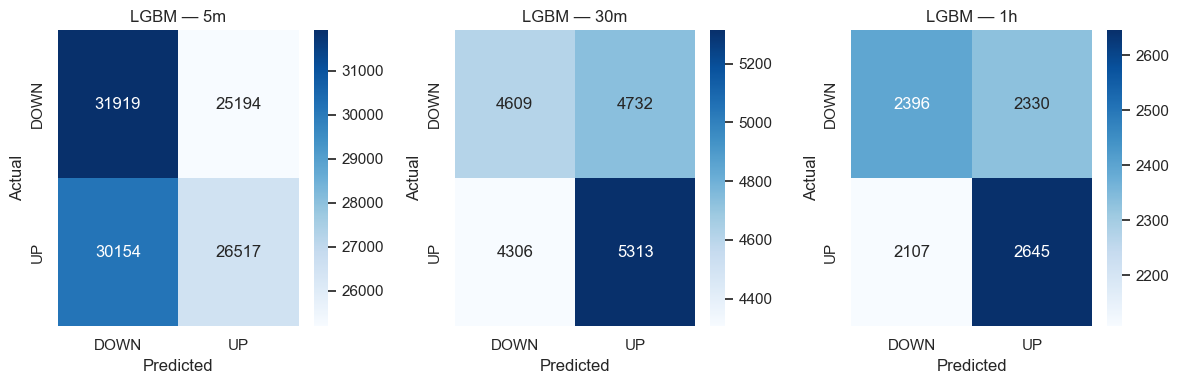

In [5]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(12, 4))

for ax, label in zip(axes, HORIZONS):
    res = all_results[label]['lgbm']
    plot_confusion_matrix(
        res['y_true'], res['y_pred'],
        title=f'LGBM — {label}',
        ax=ax,
    )

plt.tight_layout()
plt.show()


## 5. ROC Curves

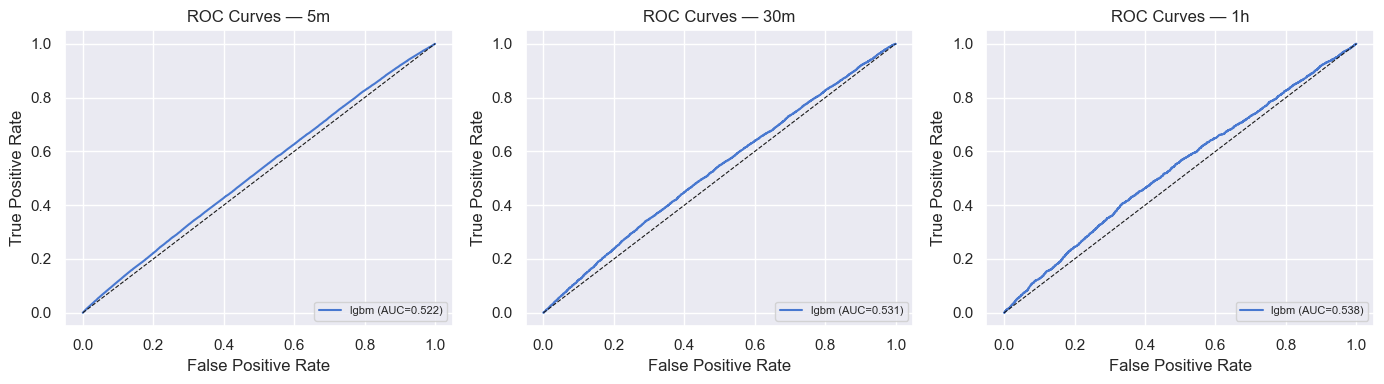

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, label in zip(axes, HORIZONS):
    plot_roc_curves(
        all_results[label],
        ax=ax,
        title=f'ROC Curves — {label}',
    )

plt.tight_layout()
plt.show()

## 6. Calibration Curves

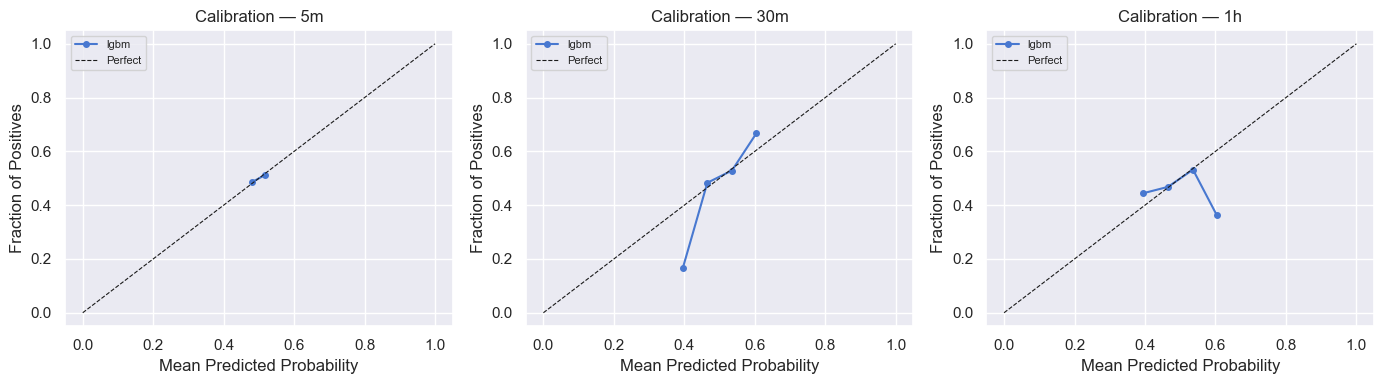

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, label in zip(axes, HORIZONS):
    plot_calibration(
        all_results[label],
        ax=ax,
        title=f'Calibration — {label}',
    )

plt.tight_layout()
plt.show()

## 7. Prediction Confidence Distribution

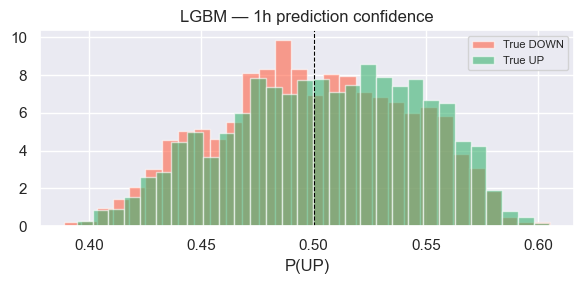

In [8]:
label = '1h'
res = all_results[label]['lgbm']
probs = res['y_prob']
true  = res['y_true'].astype(int)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(probs[true == 0], bins=30, alpha=0.6, color='tomato',
        density=True, label='True DOWN')
ax.hist(probs[true == 1], bins=30, alpha=0.6, color='mediumseagreen',
        density=True, label='True UP')
ax.axvline(0.5, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'LGBM — {label} prediction confidence')
ax.set_xlabel('P(UP)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 8. Final Summary Table

In [9]:
results_df = aggregate_results(all_results)
print_results_table(results_df)

               accuracy  precision  recall      f1  roc_auc
horizon model                                              
5m      lgbm     0.5136     0.5128  0.4679  0.4893   0.5223
30m     lgbm     0.5233     0.5289  0.5523  0.5404   0.5315
1h      lgbm     0.5319     0.5317  0.5566  0.5438   0.5377


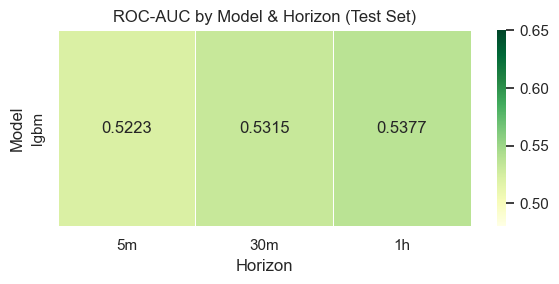

In [10]:
# Heatmap of ROC-AUC across model × horizon
auc_pivot = results_df['roc_auc'].unstack(level='horizon')[HORIZONS]

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(
    auc_pivot, annot=True, fmt='.4f', cmap='YlGn',
    vmin=0.48, vmax=0.65, linewidths=0.5, ax=ax,
)
ax.set_title('ROC-AUC by Model & Horizon (Test Set)')
ax.set_xlabel('Horizon')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

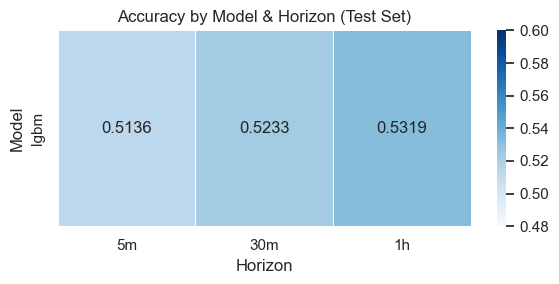

In [11]:
# Heatmap of Accuracy
acc_pivot = results_df['accuracy'].unstack(level='horizon')[HORIZONS]

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(
    acc_pivot, annot=True, fmt='.4f', cmap='Blues',
    vmin=0.48, vmax=0.60, linewidths=0.5, ax=ax,
)
ax.set_title('Accuracy by Model & Horizon (Test Set)')
ax.set_xlabel('Horizon')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

## 9. Walk-Forward Validation

[LGBM] Training …


[LightGBM] [Info] Number of positive: 227742, number of negative: 227393
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001892 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3346
[LightGBM] [Info] Number of data points in the train set: 455135, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500383 -> initscore=0.001534
[LightGBM] [Info] Start training from score 0.001534


[LGBM] Best iteration: 0
[WFV] 5m  window 1/8  train=455,135  val=37,928  acc=0.5305  auc=0.5459
[LGBM] Training …


/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 246333, number of negative: 246730
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002518 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3346
[LightGBM] [Info] Number of data points in the train set: 493063, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499597 -> initscore=-0.001610
[LightGBM] [Info] Start training from score -0.001610


...

/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LGBM] Best iteration: 0
[WFV] 1h  window 7/8  train=56,864  val=3,159  acc=0.5160  auc=0.5321
[LGBM] Training …
[LightGBM] [Info] Number of positive: 30499, number of negative: 29524
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3346
[LightGBM] [Info] Number of data points in the train set: 60023, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508122 -> initscore=0.032490
[LightGBM] [Info] Start training from score 0.032490


/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LGBM] Best iteration: 0
[WFV] 1h  window 8/8  train=60,023  val=3,160  acc=0.5193  auc=0.5345


/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


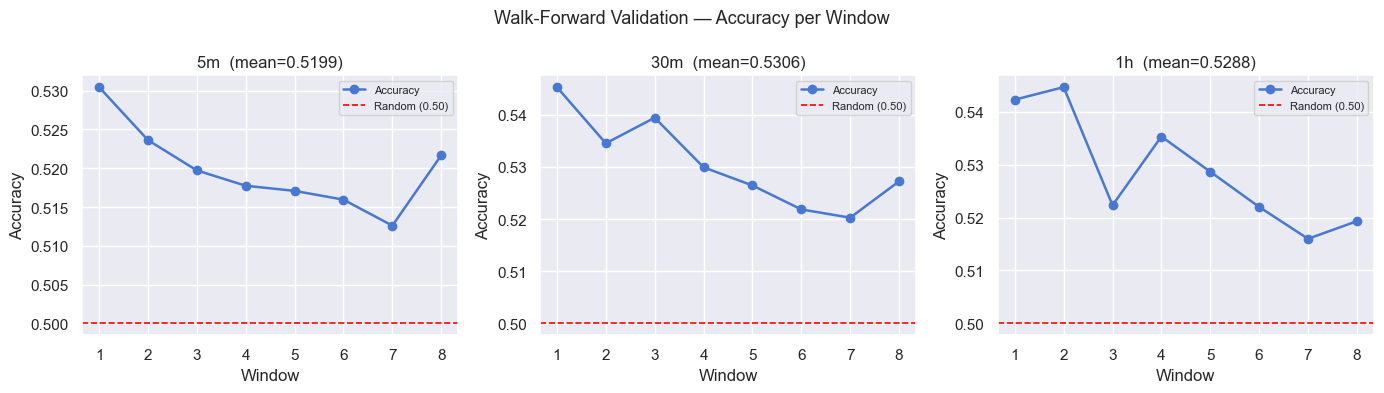


Walk-Forward Validation Summary
Horizon      Mean Acc    Std Acc
--------------------------------
5m             0.5199     0.0051
30m            0.5306     0.0081
1h             0.5288     0.0101


In [12]:
# ── Section 9: Walk-Forward Validation ──────────────────────────────────────
# Expanding-window approach: initial training = 60%, each window adds ~5%.
# Validation window = next 5% of data after training end.
# 8 windows per horizon, fresh LightGBM trained on each window.

np.random.seed(42)

N_WINDOWS        = 8
INIT_TRAIN_FRAC  = 0.60   # first training window fraction
STEP_FRAC        = 0.05   # how much to grow training each window
VAL_FRAC         = 0.05   # validation window size

wfv_results = {}   # {horizon: {'acc': [...], 'auc': [...]}}

for label in HORIZONS:
    df = feat_frames[label]
    feat_cols = get_feature_cols(df)
    X_all = df[feat_cols].values.astype(np.float32)
    y_all = df['target'].values.astype(np.float32)
    n     = len(y_all)

    accs, aucs = [], []

    for w in range(N_WINDOWS):
        train_end = int(n * (INIT_TRAIN_FRAC + w * STEP_FRAC))
        val_end   = int(n * (INIT_TRAIN_FRAC + w * STEP_FRAC + VAL_FRAC))
        # Guard against running past the end of the data
        if val_end > n:
            print(f'[WFV] {label} window {w+1}: not enough data, skipping.')
            break

        X_tr, y_tr = X_all[:train_end],       y_all[:train_end]
        X_vl, y_vl = X_all[train_end:val_end], y_all[train_end:val_end]

        # Train a fresh LightGBM model (same default params as src/models.py)
        wfv_model = LightGBMModel()
        # Suppress verbose output by overriding n_estimators for speed;
        # keep all other hyper-parameters at their defaults.
        wfv_model.train(X_tr, y_tr)  # no validation set → no early stopping

        y_pred = wfv_model.predict(X_vl)
        y_prob = wfv_model.predict_proba(X_vl)

        from sklearn.metrics import accuracy_score, roc_auc_score
        acc = accuracy_score(y_vl, y_pred)
        try:
            auc = roc_auc_score(y_vl, y_prob)
        except Exception:
            auc = float('nan')

        accs.append(acc)
        aucs.append(auc)
        print(f'[WFV] {label}  window {w+1}/{N_WINDOWS}  '
              f'train={train_end:,}  val={val_end-train_end:,}  '
              f'acc={acc:.4f}  auc={auc:.4f}')

    wfv_results[label] = {'acc': accs, 'auc': aucs}

# ── Plot: accuracy per window, one subplot per horizon ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
fig.suptitle('Walk-Forward Validation — Accuracy per Window', fontsize=13)

for ax, label in zip(axes, HORIZONS):
    accs = wfv_results[label]['acc']
    windows = list(range(1, len(accs) + 1))
    mean_acc = np.mean(accs)

    ax.plot(windows, accs, marker='o', linewidth=1.8, label='Accuracy')
    ax.axhline(0.50, color='red', linestyle='--', linewidth=1.2, label='Random (0.50)')
    ax.set_title(f'{label}  (mean={mean_acc:.4f})')
    ax.set_xlabel('Window')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(windows)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\nWalk-Forward Validation Summary')
print(f'{"Horizon":<10} {"Mean Acc":>10} {"Std Acc":>10}')
print('-' * 32)
for label in HORIZONS:
    accs = wfv_results[label]['acc']
    print(f'{label:<10} {np.mean(accs):>10.4f} {np.std(accs):>10.4f}')


## 10. Permutation Test

[Perm] 5m  real_acc=0.5136  null_mean=0.5003  p=0.0000
[Perm] 30m  real_acc=0.5233  null_mean=0.5004  p=0.0000
[Perm] 1h  real_acc=0.5319  null_mean=0.4997  p=0.0000


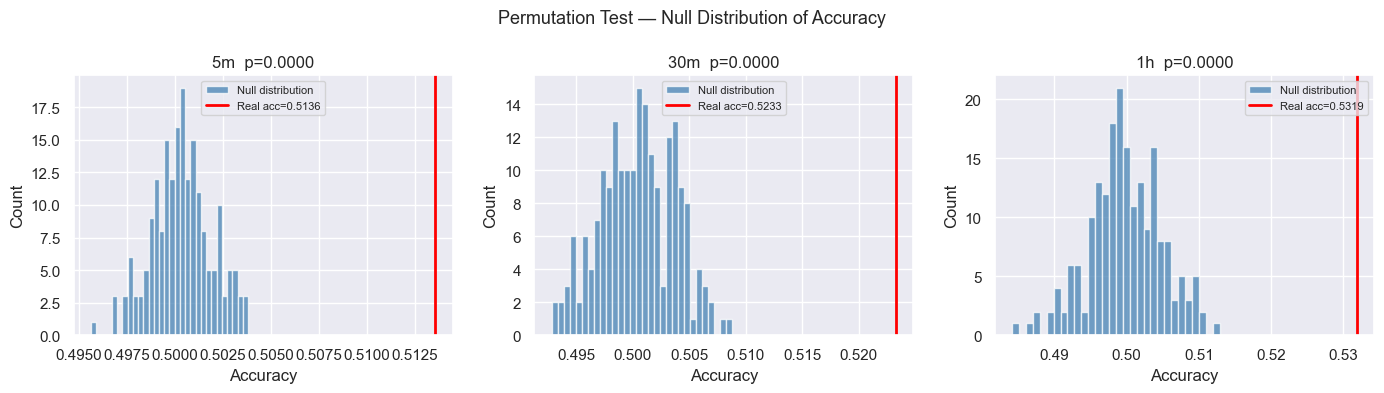


Permutation Test Conclusions (alpha = 0.05)
Horizon      Real Acc    p-value          Result
--------------------------------------------------
5m             0.5136     0.0000     SIGNIFICANT
30m            0.5233     0.0000     SIGNIFICANT
1h             0.5319     0.0000     SIGNIFICANT


In [13]:
# ── Section 10: Permutation Test ────────────────────────────────────────────
# For each horizon: shuffle the true test labels 200 times and record the
# accuracy of the *real model's predictions* against the shuffled labels.
# p-value = fraction of permutations that reach or exceed the true accuracy.

np.random.seed(42)

N_PERMUTATIONS = 200

perm_results = {}   # {horizon: {'null_accs': [...], 'real_acc': float, 'pval': float}}

from sklearn.metrics import accuracy_score

for label in HORIZONS:
    res      = all_results[label]['lgbm']
    y_pred   = res['y_pred']          # real model predictions (fixed)
    y_test   = res['y_true']          # true labels from the held-out test set
    real_acc = accuracy_score(y_test, y_pred)

    null_accs = []
    for _ in range(N_PERMUTATIONS):
        y_shuffled = np.random.permutation(y_test)
        null_accs.append(accuracy_score(y_shuffled, y_pred))

    null_accs = np.array(null_accs)
    pval      = np.mean(null_accs >= real_acc)

    perm_results[label] = {
        'null_accs': null_accs,
        'real_acc':  real_acc,
        'pval':      pval,
    }
    print(f'[Perm] {label}  real_acc={real_acc:.4f}  '
          f'null_mean={null_accs.mean():.4f}  p={pval:.4f}')

# ── Plot: null distribution histograms ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Permutation Test — Null Distribution of Accuracy', fontsize=13)

for ax, label in zip(axes, HORIZONS):
    pr       = perm_results[label]
    real_acc = pr['real_acc']
    pval     = pr['pval']

    ax.hist(pr['null_accs'], bins=30, color='steelblue', edgecolor='white',
            alpha=0.75, label='Null distribution')
    ax.axvline(real_acc, color='red', linewidth=2.0,
               label=f'Real acc={real_acc:.4f}')
    ax.set_title(f'{label}  p={pval:.4f}')
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Conclusion ────────────────────────────────────────────────────────────────
print('\nPermutation Test Conclusions (alpha = 0.05)')
print(f'{"Horizon":<10} {"Real Acc":>10} {"p-value":>10} {"Result":>15}')
print('-' * 50)
for label in HORIZONS:
    pr     = perm_results[label]
    sig    = 'SIGNIFICANT' if pr['pval'] < 0.05 else 'NOT SIGNIFICANT'
    print(f'{label:<10} {pr["real_acc"]:>10.4f} {pr["pval"]:>10.4f} {sig:>15}')


### Live Prediction (Single-Shot)
Fetches the latest candles from Binance, builds features, and runs the LightGBM 1h model — no terminal needed.

In [16]:
import warnings, pickle
import numpy as np
import pandas as pd
from datetime import datetime, timezone
from binance.client import Client
from src.features import build_features, get_feature_cols

warnings.filterwarnings('ignore')

# Config
INTERVAL   = '1h'
N_CANDLES  = 248
MODEL_PATH = MODEL_DIR / 'lgbm_1h.pkl'
OHLCV_COLS = ['open', 'high', 'low', 'close', 'volume']

# Fetch latest candles from Binance
client = Client()
klines = client.get_klines(symbol='BTCUSDT', interval=INTERVAL, limit=N_CANDLES + 1)

df = pd.DataFrame(klines, columns=[
    'open_time','open','high','low','close','volume',
    'close_time','quote_volume','num_trades',
    'taker_buy_base','taker_buy_quote','ignore'
])
df['timestamp'] = pd.to_datetime(df['open_time'], unit='ms', utc=True)
df = df.set_index('timestamp')[OHLCV_COLS].astype(float)
df = df.iloc[:-1]  # drop still-open candle

# Build features
featured  = build_features(df, drop_na=False)
featured  = featured.dropna(subset=get_feature_cols(featured))

# Load model & predict
model     = pickle.load(open(MODEL_PATH, 'rb'))
feat_cols = get_feature_cols(featured)
X         = featured[feat_cols].values[-1:].astype(np.float32)
prob      = float(model.predict_proba(X)[0][1])

# Format output
direction  = 'UP  ▲' if prob >= 0.5 else 'DOWN ▼'
confidence = max(prob, 1 - prob) * 100
last_close = df['close'].iloc[-1]

now_utc    = datetime.now(timezone.utc)
now_local  = datetime.now().astimezone()
interval_ms = 3_600_000
now_ms     = int(now_utc.timestamp() * 1000)
next_start = datetime.fromtimestamp((now_ms // interval_ms) * interval_ms / 1000)
next_end   = datetime.fromtimestamp(((now_ms // interval_ms) + 1) * interval_ms / 1000)

print('=' * 55)
print('  BTC/USDT — Live Direction Prediction (LightGBM 1h)')
print('=' * 55)
print(f'  Time (UTC):        {now_utc.strftime("%Y-%m-%d %H:%M:%S")}')
print(f'  Time (Local):      {now_local.strftime("%Y-%m-%d %H:%M:%S %Z")}')
print(f'  Last close price:  ${last_close:,.2f}')
print(f'  Predicting candle: {next_start.strftime("%H:%M")} → {next_end.strftime("%H:%M")} (local)')
print('-' * 55)
print(f'  Direction:         {direction}')
print(f'  Confidence:        {confidence:.1f}%')
print(f'  P(UP):             {prob:.4f}')
print(f'  P(DOWN):           {1-prob:.4f}')
print('=' * 55)


[features] Building features  (rows before: 248) …
[features] Done  (rows after: 248,  features: 15)
  BTC/USDT — Live Direction Prediction (LightGBM 1h)
  Time (UTC):        2026-03-19 19:23:53
  Time (Local):      2026-03-19 21:23:53 EET
  Last close price:  $69,821.21
  Predicting candle: 22:00 → 23:00 (local)
-------------------------------------------------------
  Direction:         DOWN ▼
  Confidence:        55.8%
  P(UP):             0.4417
  P(DOWN):           0.5583
